Importing the libraries.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Reading the dataset(only 1st 3 columns).

In [12]:
df = pd.read_csv('Datasets/wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']
print(df.head())
print(df.shape)

   Class label  Alcohol  Malic acid
0            1    14.23        1.71
1            1    13.20        1.78
2            1    13.16        2.36
3            1    14.37        1.95
4            1    13.24        2.59
(178, 3)


Plotting a densty graph for 'Alcohol' and 'Malic acid' using seaborn's kdeplot. Firstly we make a space for 2 graph using fig and initializing the graphs via ax1,ax2.

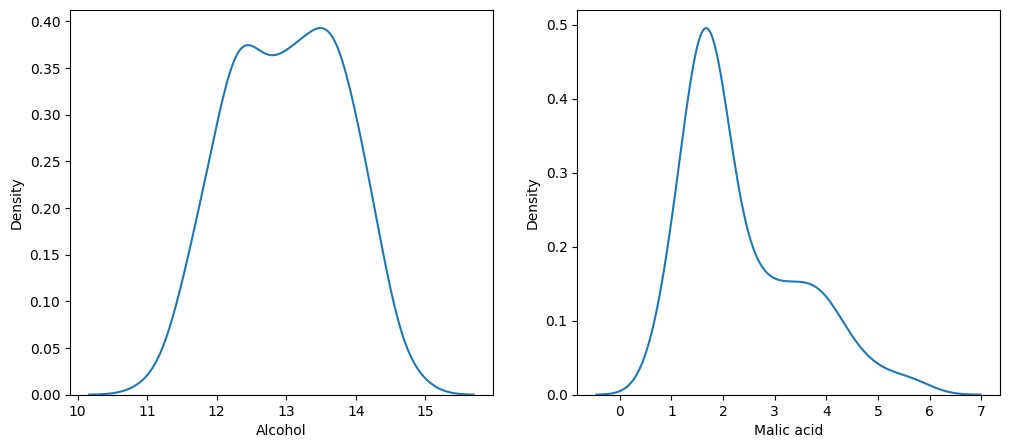

In [13]:
fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))
sns.kdeplot(df['Alcohol'], ax=ax1)
sns.kdeplot(df['Malic acid'], ax=ax2)
plt.show()

Scatterplottig the Alcohol and Malic acid on x and y axis, with column Class label as hue and 3 colors to show them.

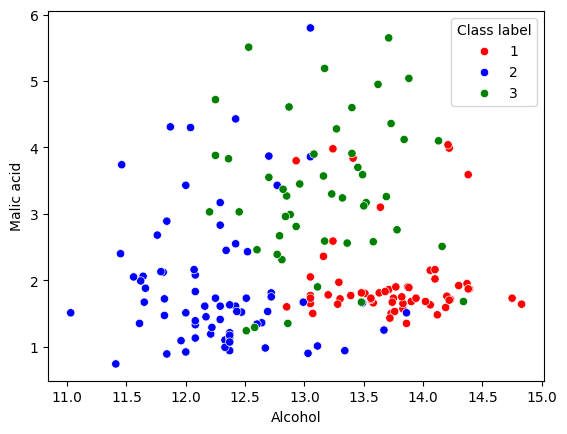

In [14]:
color = {1:'red',2:'blue',3:'green'}
sns.scatterplot(x='Alcohol', y='Malic acid', hue='Class label', data=df, palette=color)
plt.show()

Splitting the data into x and y, train and test.

In [15]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1), df['Class label'],test_size=0.3, random_state=0)
x_train.shape, x_test.shape

((124, 2), (54, 2))

MinMaxScaler - Most frequent used Normalization technique,

.fit - Learns from the parameters, it compute several thing from the data (min, max, range etc)

Test data should not be studied prior ( via .fit) because the model must not learn from the test data, this create a Data Leakage as model knows the data which is supposed to not know yet.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

np.round(x_train_scaled.describe(), 2)

,Alcohol,Malic acid
count,124.00,124.00
mean,0.53,0.31
std,0.22,0.24
min,0.00,0.00
25%,0.36,0.15
50%,0.54,0.21
75%,0.70,0.50
max,1.00,1.00


Showing the comparision between prior and post normalizatin via scatterplot.

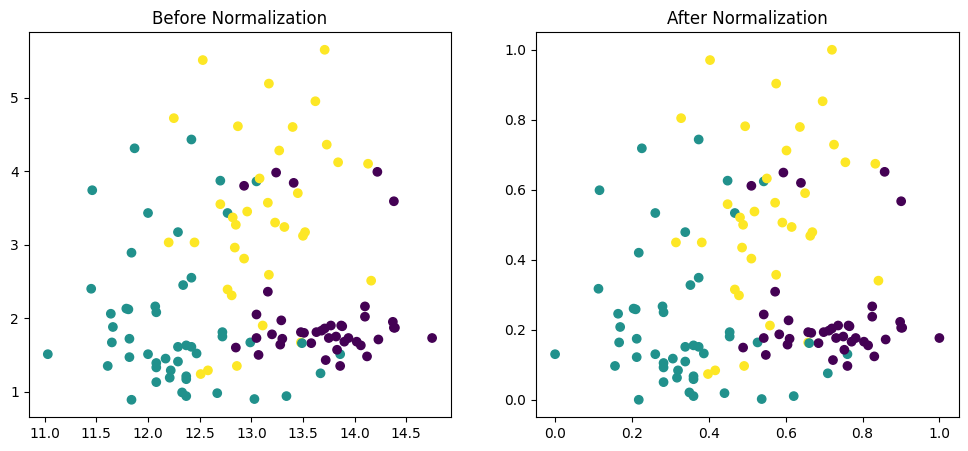

In [17]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(x_train['Alcohol'], x_train['Malic acid'], c=y_train,)
ax1.set_title('Before Normalization')
ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic acid'], c=y_train)
ax2.set_title('After Normalization')
plt.show()

Plotting the comparision density curves.

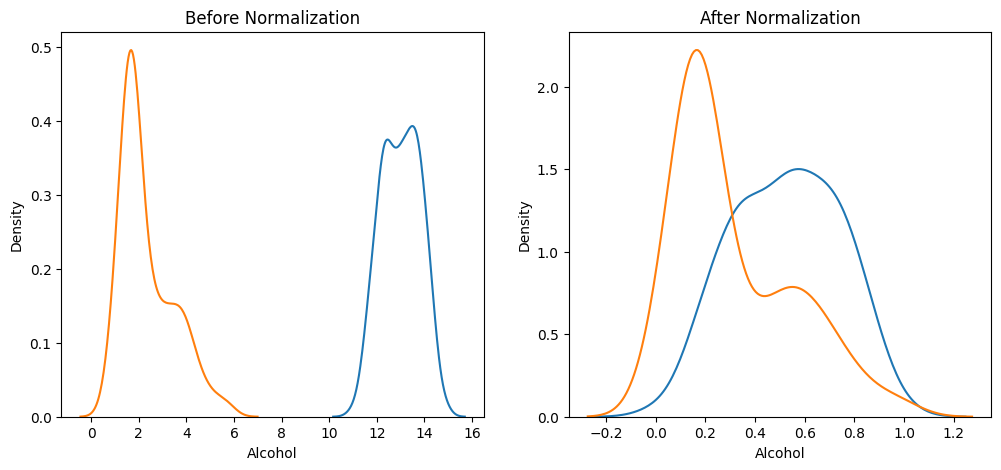

In [18]:
fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))
sns.kdeplot(df['Alcohol'], ax=ax1)
sns.kdeplot(df['Malic acid'], ax=ax1)
ax1.set_title("Before Normalization")
ax2.set_title("After Normalization")
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2)
plt.show()

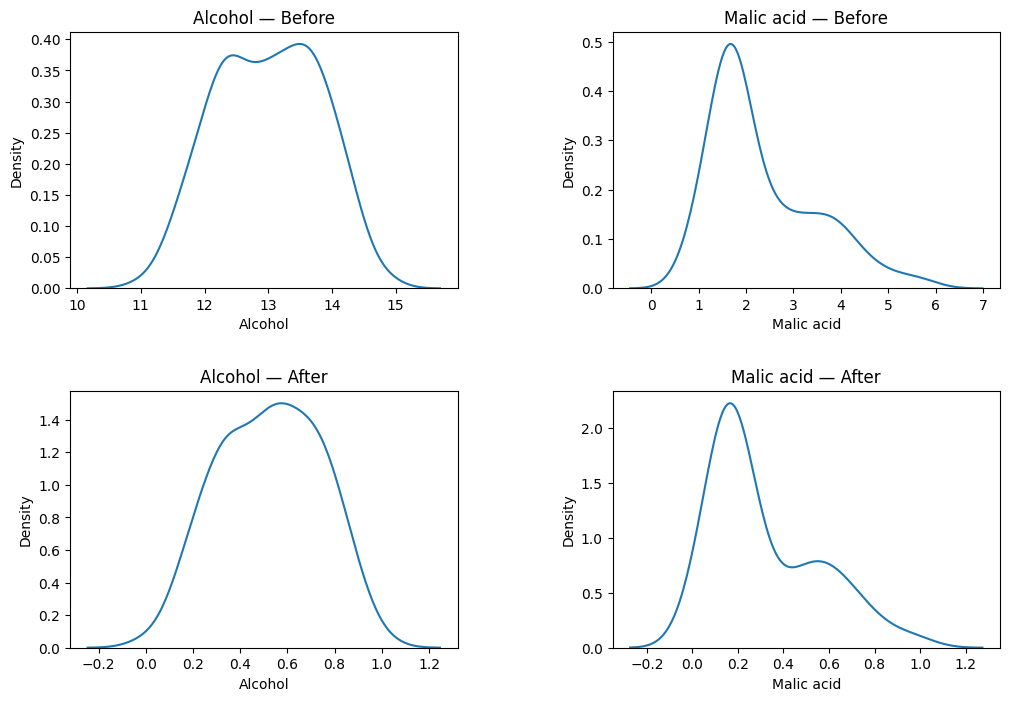

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.kdeplot(df['Alcohol'], ax=axes[0, 0])
axes[0, 0].set_title("Alcohol — Before")

sns.kdeplot(df['Malic acid'], ax=axes[0, 1])
axes[0, 1].set_title("Malic acid — Before")

sns.kdeplot(x_train_scaled['Alcohol'], ax=axes[1, 0])
axes[1, 0].set_title("Alcohol — After")

sns.kdeplot(x_train_scaled['Malic acid'], ax=axes[1, 1])
axes[1, 1].set_title("Malic acid — After")

fig.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()